In [3]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt


In [4]:
arquivo = 'dados_tratados.csv'

df = pd.read_csv(arquivo)
df

,ids,titles,abstracts,cs.AI,cs.AR,cs.CC,cs.CE,cs.CG,cs.CL,cs.CR,...,cs.OH,cs.OS,cs.PF,cs.PL,cs.RO,cs.SC,cs.SD,cs.SE,cs.SI,cs.SY
0,2308.14524,Towards enabling reliable immersive teleoperat...,This paper addresses the challenging problem...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2306.17702,Why Deep Models Often cannot Beat Non-deep Cou...,Molecular property prediction (MPP) is a cru...,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2203.06430,Categories of Differentiable Polynomial Circui...,Reverse derivative categories (RDCs) have re...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2310.16175,G-CASCADE: Efficient Cascaded Graph Convolutio...,"In recent years, medical image segmentation ...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1706.10076,Chatbots as Conversational Recommender Systems...,"In this paper, we outline the vision of chat...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76877,2010.07000,Analytical parameter estimation of the SIR epi...,The dramatic outbreak of the coronavirus dis...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
76878,2306.03487,Compiling Quantum Circuits for Dynamically Fie...,Dynamically field-programmable qubit arrays ...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
76879,1704.00961,Adaptive Motion Gaming AI for Health Promotion,This paper presents a design of a non-player...,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
76880,1308.38920,Do the rich get richer? An empirical analysis ...,The possibility to analyze everyday monetary...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


# Index das colunas

In [5]:
colunas = df.columns[3:]
colunas

Index(['cs.AI', 'cs.AR', 'cs.CC', 'cs.CE', 'cs.CG', 'cs.CL', 'cs.CR', 'cs.CV',
       'cs.CY', 'cs.DB', 'cs.DC', 'cs.DL', 'cs.DM', 'cs.DS', 'cs.ET', 'cs.FL',
       'cs.GL', 'cs.GR', 'cs.GT', 'cs.HC', 'cs.IR', 'cs.IT', 'cs.LG', 'cs.LO',
       'cs.MA', 'cs.MM', 'cs.MS', 'cs.NA', 'cs.NE', 'cs.NI', 'cs.OH', 'cs.OS',
       'cs.PF', 'cs.PL', 'cs.RO', 'cs.SC', 'cs.SD', 'cs.SE', 'cs.SI', 'cs.SY'],
      dtype='object')

# Grafico mostrando quantidade de cada categoria

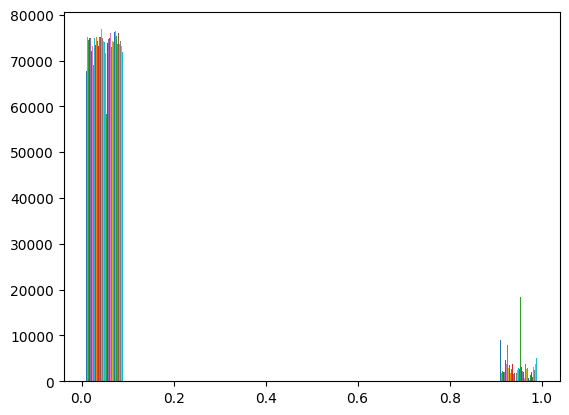

In [6]:
plt.hist(x = df[colunas])
plt.show()

In [7]:
contagem_categorias = df[colunas].sum()

# formatando result
contagem_df = contagem_categorias.reset_index()
contagem_df.columns = ['Categoria', 'Numero de Artigos']
contagem_df = contagem_df.sort_values(by='Numero de Artigos', ascending=False)

print(contagem_df)


   Categoria  Numero de Artigos
22     cs.LG              18456
0      cs.AI               9073
7      cs.CV               7918
21     cs.IT               5238
39     cs.SY               5069
5      cs.CL               4744
27     cs.NA               3808
38     cs.SI               3723
13     cs.DS               3713
6      cs.CR               3675
10     cs.DC               3533
34     cs.RO               3349
36     cs.SD               3192
23     cs.LO               3089
8      cs.CY               2970
29     cs.NI               2879
19     cs.HC               2828
28     cs.NE               2682
20     cs.IR               2640
12     cs.DM               2614
37     cs.SE               2529
18     cs.GT               2514
2      cs.CC               2292
24     cs.MA               2172
3      cs.CE               2052
33     cs.PL               2021
4      cs.CG               1987
25     cs.MM               1971
9      cs.DB               1963
17     cs.GR               1865
1      c

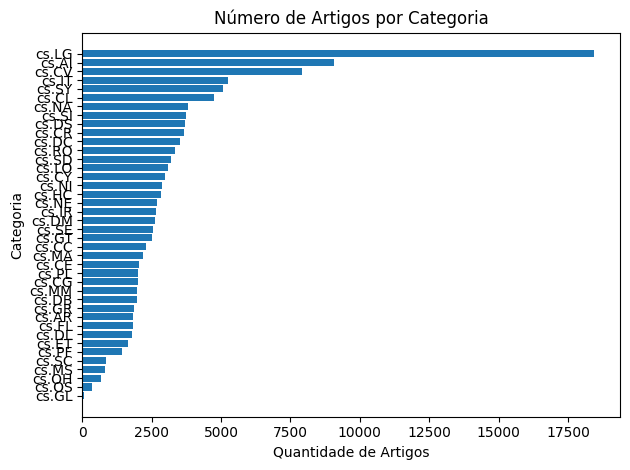

In [8]:
# graph de barras

# maior barra no topo, entao inverto o df
contagem_df_invertido = contagem_df.sort_values(by='Numero de Artigos', ascending=True)

# barras horizontais
plt.barh(y=contagem_df_invertido['Categoria'], width=contagem_df_invertido['Numero de Artigos'])

# titulos
plt.title('Número de Artigos por Categoria')
plt.xlabel('Quantidade de Artigos')
plt.ylabel('Categoria')

# ajustar layout
plt.tight_layout()

In [9]:
print(colunas)
colunas = list(colunas)

Index(['cs.AI', 'cs.AR', 'cs.CC', 'cs.CE', 'cs.CG', 'cs.CL', 'cs.CR', 'cs.CV',
       'cs.CY', 'cs.DB', 'cs.DC', 'cs.DL', 'cs.DM', 'cs.DS', 'cs.ET', 'cs.FL',
       'cs.GL', 'cs.GR', 'cs.GT', 'cs.HC', 'cs.IR', 'cs.IT', 'cs.LG', 'cs.LO',
       'cs.MA', 'cs.MM', 'cs.MS', 'cs.NA', 'cs.NE', 'cs.NI', 'cs.OH', 'cs.OS',
       'cs.PF', 'cs.PL', 'cs.RO', 'cs.SC', 'cs.SD', 'cs.SE', 'cs.SI', 'cs.SY'],
      dtype='object')


# Tratamento de dados para mostrar a quantidade de artigos com apenas 1 classificação

In [10]:
lista_dados_unitarios = []
for i in colunas:
    condicao_principal = (df[i]==1)
    colunas_exclusao = colunas.copy()
    colunas_exclusao.remove(i)
    condicao_exclusao = (df[colunas_exclusao].sum(axis=1) == 0)
    artigos_unicos = df[condicao_principal & condicao_exclusao]
    lista_dados_unitarios.append(artigos_unicos)

print(lista_dados_unitarios[1])



              ids                                             titles  \
59     2310.16844  Hardware-Algorithm Co-design Enabling Processi...   
174    2404.18562  Time Reversal for Near-Field Communications on...   
344    1606.06454  Soft GPGPUs for Embedded FPGAs: An Architectur...   
966    2205.11088  FAST: A Fully-Concurrent Access Technique to A...   
1077   1508.07139  Using System Hyper Pipelining (SHP) to Improve...   
...           ...                                                ...   
76502  1201.09540  Information Analysis Infrastructure for Diagnosis   
76563  2201.08656  Dustin: A 16-Cores Parallel Ultra-Low-Power Cl...   
76626  2402.03533  A 0.5V, 6.2$\mu$W, 0.059mm$^{2}$ Sinusoidal Cu...   
76789  2403.15069  Allspark: Workload Orchestration for Visual Tr...   
76831  2403.09070  Analytical Heterogeneous Die-to-Die 3D Placeme...   

                                               abstracts  cs.AI  cs.AR  cs.CC  \
59       The high volume of data transmission between.

# Criando um arquivo csv com os artigos com categoria unica

In [11]:
df_final = pd.concat(lista_dados_unitarios, ignore_index=True)
nome_do_arquivo = 'artigos_de_categoria_unica.csv'

df_final.to_csv(nome_do_arquivo, 
                index=False, # Não salva o índice do DataFrame como uma coluna
                encoding='utf-8') # Garante que caracteres especiais sejam salvos corretamente



# Lendo o novo arquivo criado

In [12]:
df_unitario = pd.read_csv('artigos_de_categoria_unica.csv')

Sucesso! O gráfico foi gerado e salvo como 'grafico_categorias_puras.png'.
As contagens (do maior para o menor) são:
cs.AI  cs.AR  cs.CC  cs.CE  cs.CG  cs.CL  cs.CR  cs.CV  cs.CY  cs.DB  cs.DC  cs.DL  cs.DM  cs.DS  cs.ET  cs.FL  cs.GL  cs.GR  cs.GT  cs.HC  cs.IR  cs.IT  cs.LG  cs.LO  cs.MA  cs.MM  cs.MS  cs.NA  cs.NE  cs.NI  cs.OH  cs.OS  cs.PF  cs.PL  cs.RO  cs.SC  cs.SD  cs.SE  cs.SI  cs.SY
0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      1      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0        4559
                                                                                                                                                   1      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0        3210
                              

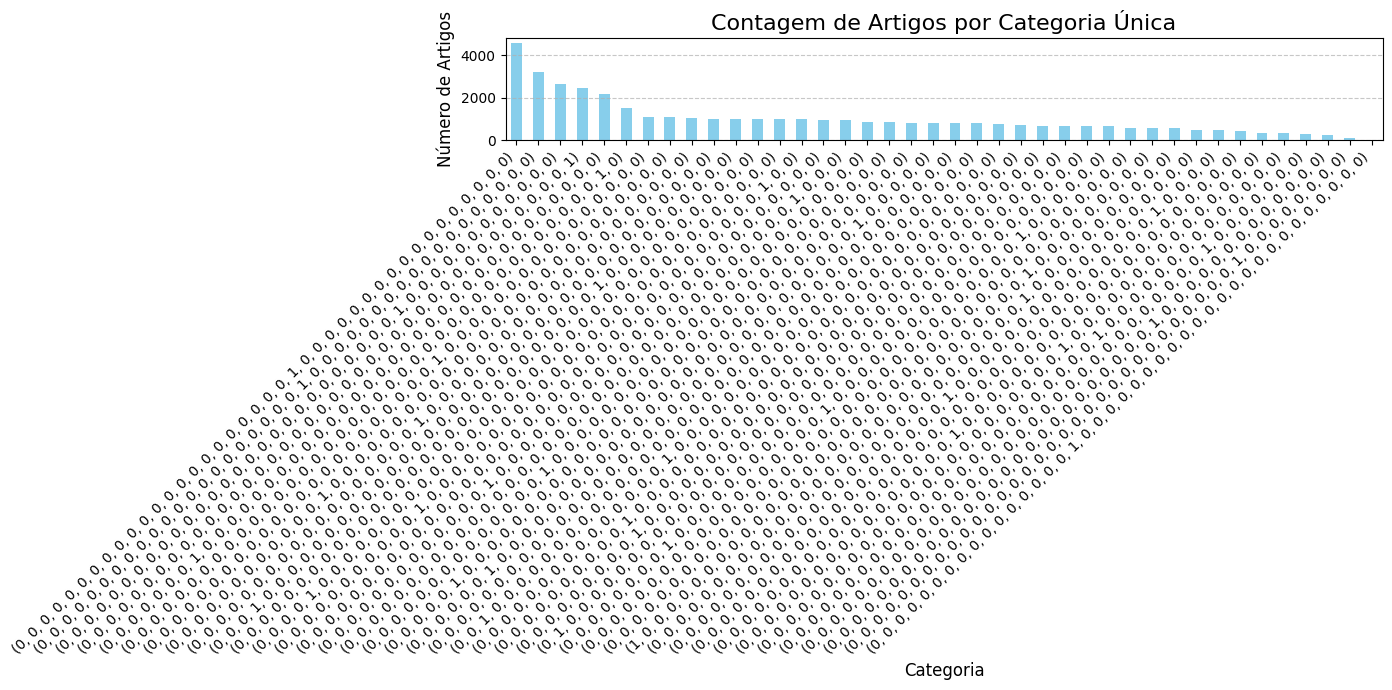

In [13]:
contagem_categorias = df_unitario[colunas].value_counts()

# 3. Criar o Gráfico de Barras

plt.figure(figsize=(14, 7))

# Gerar o gráfico usando a Série de contagens
contagem_categorias.plot(
    kind='bar',
    color='skyblue'
)

# Configurações do gráfico
plt.title('Contagem de Artigos por Categoria Única', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Número de Artigos', fontsize=12)

# Rotacionar os rótulos do eixo X para melhor legibilidade
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salvar o gráfico em um arquivo PNG
plt.savefig('grafico_categorias_puras.png')

print("Sucesso! O gráfico foi gerado e salvo como 'grafico_categorias_puras.png'.")
print("As contagens (do maior para o menor) são:")
print(contagem_categorias)